In [ ]:
!pip install torch torchvision numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 54.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 67.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

## 1- Import der Bibliotheken

In [ ]:
# Schritt 1: Import der Bibliotheken
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## 2- Daten Vorbereitung und Herunterladen

In [ ]:
# Schritt 2: Datenvorbereitung

# Transformationen (Normalisierung und ggf. Augmentierung)
# Transformation festlegen: Bilder in Tensor umwandeln und normalisieren


transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),  # Augmentierung nur hier!
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.4914, 0.4822, 0.4465),
                         std=(0.2023, 0.1994, 0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.4914, 0.4822, 0.4465),
                         std=(0.2023, 0.1994, 0.2010))
])

In [ ]:
# CIFAR-10 Trainings und Testsdatensatz herunterladen

# Gesamter Trainingsdatensatz laden (mit Augmentierung)
trainset = datasets.CIFAR10(root='./data', train=True,
                                             download=True, transform=transform_train)

# Testdatensatz laden (ohne Augmentierung)
testset = datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform_test)


100%|██████████| 170M/170M [00:03<00:00, 45.6MB/s]


In [ ]:
print(f'Trainingsdaten: {len(trainset)}')

print(f'Testdaten: {len(testset)}')

Trainingsdaten: 50000
Testdaten: 10000


In [ ]:
# Trainingsdaten aufteilen in Training und Validierung (80/20)
train_size = int(0.8 * len(trainset))
val_size = len(trainset) - train_size

trainset, valset = torch.utils.data.random_split(trainset, [train_size, val_size])


In [ ]:
# Ausgabe zur Kontrolle
print(f'Trainingsdaten: {len(trainset)}')
print(f'Validierungsdaten: {len(valset)}')
print(f'Testdaten: {len(testset)}')

Trainingsdaten: 40000
Validierungsdaten: 10000
Testdaten: 10000


In [ ]:
# DataLoader erzeugen (Batchgröße = 4)

# DataLoader erstellen
train_loader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True, num_workers=2)
val_loader = torch.utils.data.DataLoader(valset, batch_size=64, shuffle=False, num_workers=2)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False, num_workers=2)



In [ ]:
# Klassen definieren (auf Deutsch)
classes = ('Flugzeug', 'Auto', 'Vogel', 'Katze', 'Hirsch',
           'Hund', 'Frosch', 'Pferd', 'Schiff', 'LKW')

## Visualisieren der Dateibildern

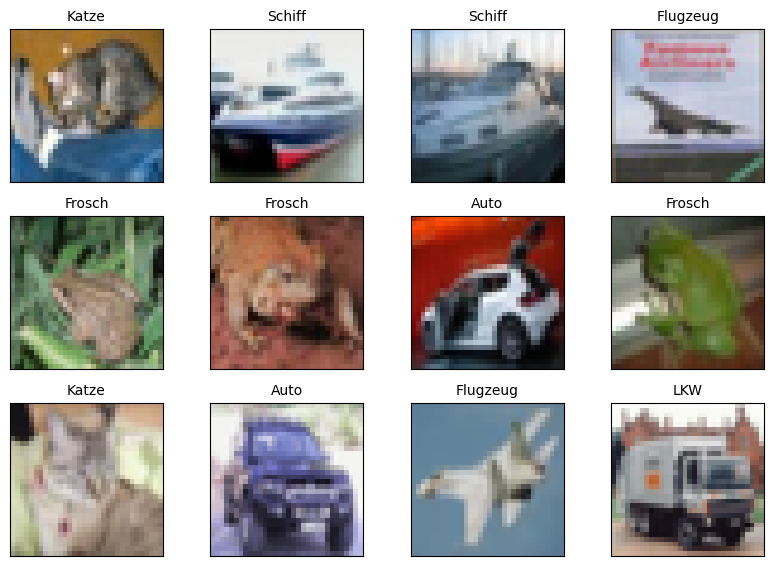

In [ ]:
# Beispielbilder aus Testdaten holen
examples = enumerate(testloader)
batch_idx, (example_data, example_targets) = next(examples)

# Funktion zum Denormalisieren der Bilder
def imshow(img):
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2023, 0.1994, 0.2010])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)

# Visualisierung von 12 kleinen Beispielbildern (4x3 Layout)
fig = plt.figure(figsize=(8,6))
for i in range(12):
    plt.subplot(3, 4, i+1)
    plt.tight_layout()
    imshow(example_data[i])
    plt.title(f"{classes[example_targets[i]]}", fontsize=10)
    plt.xticks([])
    plt.yticks([])

plt.show()


## Modelldefinition für CIFAR-10

In [ ]:
import torch.nn as nn
import torch.optim as optim

# Modelldefinition angepasst auf CIFAR-10
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(64 * 8 * 8, 128)  # <-- wichtig: 64 * 8 * 8 (für CIFAR-10)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))  # 32x32 -> 16x16
        x = self.pool(torch.relu(self.conv2(x)))  # 16x16 -> 8x8
        x = torch.flatten(x, 1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Modell initialisieren
model = CNN()

# GPU verwenden, falls verfügbar
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# Verlustfunktion und Optimierer definieren
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


## Training und Validierung definieren

In [ ]:
num_epochs = 10  # Anzahl der Epochen festlegen

# Listen für Ergebnisse
train_losses, val_losses = [], []
train_acc, val_acc = [], []

for epoch in range(num_epochs):
    # Training
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        # Gradienten auf Null setzen
        optimizer.zero_grad()

        # Forward + Backward + Optimierung
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Verlust und Genauigkeit berechnen
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total
    train_losses.append(epoch_loss)
    train_acc.append(epoch_acc)

    # Validierung
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total_val += labels.size(0)
            correct_val += predicted.eq(labels).sum().item()

    val_epoch_loss = val_loss / len(val_loader)
    val_epoch_acc = 100. * correct_val / total_val
    val_losses.append(val_epoch_loss)
    val_acc.append(val_epoch_acc)

    print(f'Epoche [{epoch+1}/{num_epochs}] '
          f'Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.2f}% '
          f'|| Val Loss: {val_epoch_loss:.4f} | Val Acc: {val_epoch_acc:.2f}%')

print("Training abgeschlossen!")


Epoche [1/10] Train Loss: 1.3180 | Train Acc: 53.07% || Val Loss: 1.1019 | Val Acc: 61.26%
Epoche [2/10] Train Loss: 0.9726 | Train Acc: 65.97% || Val Loss: 0.9591 | Val Acc: 66.36%
Epoche [3/10] Train Loss: 0.8422 | Train Acc: 70.39% || Val Loss: 0.8744 | Val Acc: 69.91%
Epoche [4/10] Train Loss: 0.7442 | Train Acc: 74.09% || Val Loss: 0.8158 | Val Acc: 71.48%
Epoche [5/10] Train Loss: 0.6731 | Train Acc: 76.82% || Val Loss: 0.7956 | Val Acc: 72.99%
Epoche [6/10] Train Loss: 0.6084 | Train Acc: 78.76% || Val Loss: 0.7951 | Val Acc: 73.07%
Epoche [7/10] Train Loss: 0.5542 | Train Acc: 80.65% || Val Loss: 0.7867 | Val Acc: 73.55%
Epoche [8/10] Train Loss: 0.5069 | Train Acc: 82.30% || Val Loss: 0.8211 | Val Acc: 72.89%
Epoche [9/10] Train Loss: 0.4599 | Train Acc: 83.96% || Val Loss: 0.8101 | Val Acc: 73.86%
Epoche [10/10] Train Loss: 0.4144 | Train Acc: 85.53% || Val Loss: 0.8932 | Val Acc: 72.09%
Training abgeschlossen!


## 🚩 Schritt 6: Evaluation (Test-Genauigkeit berechnen)

In [ ]:
# Modell im Evaluationsmodus
model.eval()

correct = 0
total = 0
test_loss = 0.0

with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

test_accuracy = 100. * correct / total
test_loss_avg = test_loss / len(testloader)

print(f'Test Loss: {test_loss_avg:.4f}')
print(f'Test Genauigkeit: {test_accuracy:.2f}%')


Test Loss: 0.8812
Test Genauigkeit: 72.35%


In [ ]:
#Speichern der Gewichte
torch.save(model.state_dict(), 'model_weights.pth')

In [ ]:
#Laden und evaluieren des gespeicherten Modells
model.load_state_dict(torch.load('model_weights.pth', weights_only=True))
model.eval()

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

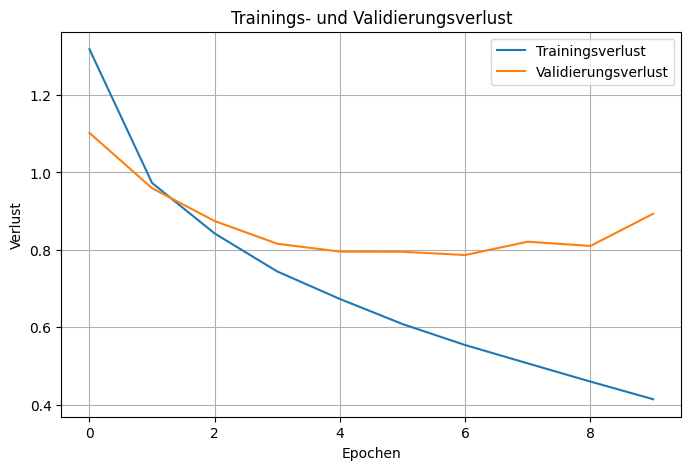

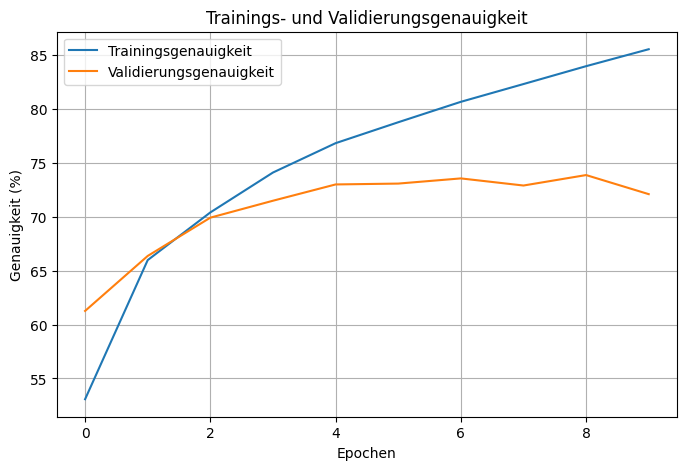

In [ ]:
# Visualisierung der Verlustkurven
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Trainingsverlust')
plt.plot(val_losses, label='Validierungsverlust')
plt.xlabel('Epochen')
plt.ylabel('Verlust')
plt.title('Trainings- und Validierungsverlust')
plt.legend()
plt.grid()
plt.show()

# Visualisierung der Genauigkeitskurven
plt.figure(figsize=(8, 5))
plt.plot(train_acc, label='Trainingsgenauigkeit')
plt.plot(val_acc, label='Validierungsgenauigkeit')
plt.xlabel('Epochen')
plt.ylabel('Genauigkeit (%)')
plt.title('Trainings- und Validierungsgenauigkeit')
plt.legend()
plt.grid()
plt.show()


 **Trainings- und Validierungsgenauigkeit** : „Die Lernkurve zeigt, dass der Trainingsverlust kontinuierlich abnimmt, was darauf hinweist, dass das Modell während des Trainings zunehmend besser lernt. Der Validierungsverlust hingegen sinkt nur bis etwa zur vierten Epoche, danach stagniert er und beginnt sogar leicht anzusteigen. Dies ist ein Hinweis auf Overfitting: das Modell beginnt sich stärker auf die Trainingsdaten zu spezialisieren und verliert seine Fähigkeit, neue, unbekannte Daten (Validierungsdaten) gut vorherzusagen.
Eine mögliche Empfehlung wäre, Methoden wie Regularisierung, frühzeitiges Stoppen (Early Stopping) oder weitere Datenaugmentation einzusetzen, um dieses Overfitting zu reduzieren.“

**Trainings- und Validierungsgenauigkeit** :